In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_trans = pd.read_csv('../data/train_transaction.csv', nrows=100000)
train_iden  = pd.read_csv('../data/train_identity.csv')

print(f"Transaction: {train_trans.shape}")
print(f"Identity: {train_iden.shape}")

Transaction: (100000, 394)
Identity: (144233, 41)


Tổng số cột có null: 319

Top 15 cột nhiều null nhất:
D7       93.9
dist2    91.8
D13      90.5
D12      89.5
D14      88.8
D6       87.3
M8       84.0
M7       84.0
M9       84.0
D8       78.3
D9       78.3
V1       71.2
V7       71.2
V8       71.2
V9       71.2
dtype: float64


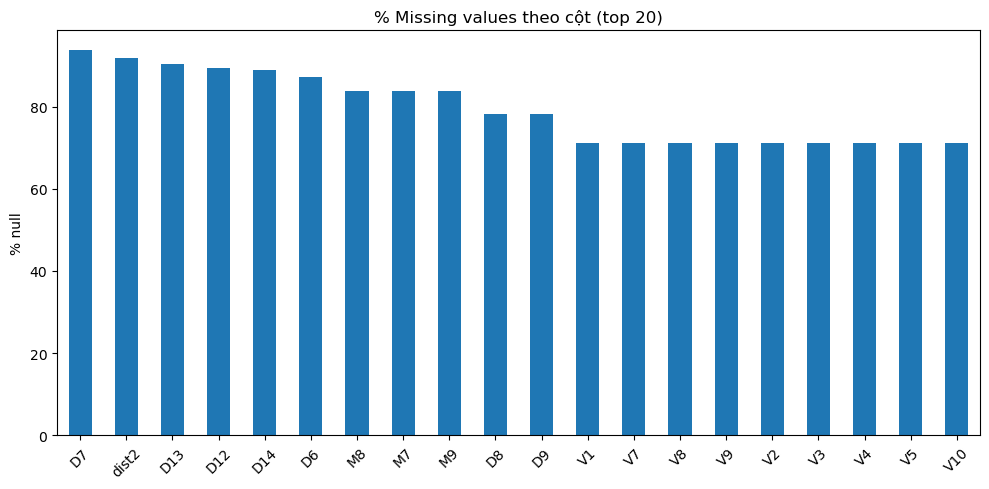

In [3]:
# Tính % null từng cột
missing_pct = (train_trans.isnull().sum() / len(train_trans) * 100)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print(f"Tổng số cột có null: {len(missing_pct)}")
print(f"\nTop 15 cột nhiều null nhất:")
print(missing_pct.head(15).round(1))

# Vẽ biểu đồ
plt.figure(figsize=(10,5))
missing_pct.head(20).plot(kind='bar')
plt.title('% Missing values theo cột (top 20)')
plt.ylabel('% null')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
# Drop cột có >50% null
threshold = 50
cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()
print(f"Số cột bị drop (>50% null): {len(cols_to_drop)}")

train_clean = train_trans.drop(columns=cols_to_drop)
print(f"Shape sau drop: {train_clean.shape}")

# Fill null còn lại
# Cột số → fill bằng median
num_cols = train_clean.select_dtypes(include=['float64','int64']).columns
train_clean[num_cols] = train_clean[num_cols].fillna(train_clean[num_cols].median())

# Cột text → fill bằng 'Unknown'
cat_cols = train_clean.select_dtypes(include=['object']).columns
train_clean[cat_cols] = train_clean[cat_cols].fillna('Unknown')

# Kiểm tra còn null không
remaining_null = train_clean.isnull().sum().sum()
print(f"\nNull còn lại sau xử lý: {remaining_null}")

Số cột bị drop (>50% null): 192
Shape sau drop: (100000, 202)

Null còn lại sau xử lý: 0


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = train_clean.select_dtypes(include=['object']).columns.tolist()
print(f"Số cột category cần encode: {len(cat_cols)}")
print(f"Tên cột: {cat_cols}")

for col in cat_cols:
    train_clean[col] = le.fit_transform(train_clean[col].astype(str))

print("\nSau encoding:")
print(train_clean[cat_cols].head(3))

Số cột category cần encode: 5
Tên cột: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M6']

Sau encoding:
   ProductCD  card4  card6  P_emaildomain  M6
0          4      2      2              0   1
1          4      3      2             17   1
2          4      4      3             36   0


In [6]:
train_clean.to_csv('../data/train_clean.csv', index=False)
print(f"Đã lưu train_clean.csv!")
print(f"Shape cuối: {train_clean.shape}")
print(f"\nPhân phối fraud sau xử lý:")
print(train_clean['isFraud'].value_counts())

Đã lưu train_clean.csv!
Shape cuối: (100000, 202)

Phân phối fraud sau xử lý:
isFraud
0    97439
1     2561
Name: count, dtype: int64


In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/train_clean.csv')
print(f"Shape: {df.shape}")
print(f"Cột TransactionDT: {df['TransactionDT'].describe()}")

Shape: (100000, 202)
Cột TransactionDT: count    1.000000e+05
mean     1.135124e+06
std      5.733484e+05
min      8.640000e+04
25%      6.537488e+05
50%      1.189342e+06
75%      1.643471e+06
max      2.006364e+06
Name: TransactionDT, dtype: float64


In [8]:
# TransactionDT là số giây tính từ một mốc cố định
# Chuyển thành các feature có ý nghĩa

df['hour']       = (df['TransactionDT'] / 3600) % 24        # Giờ trong ngày (0-23)
df['dayofweek']  = (df['TransactionDT'] / (3600*24)) % 7    # Thứ trong tuần (0-6)
df['day']        = (df['TransactionDT'] / (3600*24)) % 30   # Ngày trong tháng

print("Time features mới:")
print(df[['TransactionDT','hour','dayofweek','day']].head())

Time features mới:
   TransactionDT      hour  dayofweek       day
0          86400  0.000000   1.000000  1.000000
1          86401  0.000278   1.000012  1.000012
2          86469  0.019167   1.000799  1.000799
3          86499  0.027500   1.001146  1.001146
4          86506  0.029444   1.001227  1.001227


In [ ]:
# Dùng sample nhỏ hơn để vẽ cho nhanh
df_plot = df.sample(n=10000, random_state=42)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
fraud_by_hour = df_plot.groupby('hour')['isFraud'].mean() * 100
fraud_by_hour.plot(kind='bar', color='coral')
plt.title('Tỷ lệ Fraud theo giờ trong ngày')
plt.xlabel('Giờ')
plt.ylabel('% Fraud')

plt.subplot(1,2,2)
fraud_by_day = df_plot.groupby('dayofweek')['isFraud'].mean() * 100
fraud_by_day.plot(kind='bar', color='steelblue')
plt.title('Tỷ lệ Fraud theo thứ trong tuần')
plt.xlabel('Thứ')
plt.ylabel('% Fraud')

plt.tight_layout()
plt.show()

In [ ]:
# Sắp xếp theo thời gian trước
df = df.sort_values('TransactionDT').reset_index(drop=True)

# Số giao dịch trong cùng card (C1) gần đây
# Dùng rolling count theo card
df['card1_freq'] = df.groupby('card1')['TransactionAmt'].transform('count')
df['card1_avg_amt'] = df.groupby('card1')['TransactionAmt'].transform('mean')
df['card1_std_amt'] = df.groupby('card1')['TransactionAmt'].transform('std').fillna(0)

# Độ lệch số tiền so với trung bình của card đó
df['amt_diff_from_avg'] = df['TransactionAmt'] - df['card1_avg_amt']

print("Velocity features:")
print(df[['card1','TransactionAmt','card1_freq','card1_avg_amt','amt_diff_from_avg']].head(10))

In [ ]:
df.to_csv('../data/train_features.csv', index=False)
print(f"Đã lưu train_features.csv!")
print(f"Shape cuối: {df.shape}")
print(f"Số features mới thêm: {df.shape[1] - 202}")